<a href="https://colab.research.google.com/github/am-3/IB9AU-2026/blob/main/Task11_Flow_Matching_for_Synthetic_Floorplan_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 11 - Flow Matching for Synthetic Floorplan Generation
Atharva M
___
## Objective
This notebook demonstrates the training of a flow matching model to generate synthetic floorplan images. The primary goal is to learn the underlying data distribution of real floorplans and subsequently synthesize novel floorplan designs.
___
## Tech Stack
*   **Core Libraries:** PyTorch (for deep learning model development), `torchvision` (for image transformations and utilities).
*   **Data Handling:** `Pillow` (for image loading), `tqdm` (for progress bars).
*   **Visualization:** `matplotlib.pyplot` (for plotting images and grids).
*   **File Operations:** `zipfile`, `pathlib` (for data extraction and path management).
___
## Methodology
The task involves building and training a Conditional U-Net architecture as a flow matching model.
1.  **Data Preparation:** Floorplan images are extracted from a ZIP archive, resized, augmented (random horizontal flips), and normalized.
2.  **Model Architecture:** A simplified Conditional U-Net is employed. It takes an input image and a time step $t$ and predicts the velocity vector field. The U-Net incorporates time embeddings to condition its predictions on the current time step.
3.  **Flow Matching Training:** The model is trained using the flow matching objective. This involves sampling pairs of noisy images ($x_0$) and real images ($x_1$), interpolating them to form $x_t$ at a random time $t \in [0, 1]$, and then training the U-Net to predict the velocity vector field $v_t = x_1 - x_0$. The loss function is the Mean Squared Error (MSE) between the predicted velocity and the target velocity.
4.  **Synthetic Generation:** New floorplans are generated by starting from pure noise ($x_0$) and iteratively integrating the predicted velocity field over time from $t=0$ to $t=1$ using Euler's method. This process gradually transforms the noise into a coherent synthetic floorplan.
___
## Mathematical Formulation of Flow Matching
The core idea of flow matching is to define a continuous-time probability path between a simple base distribution (e.g., Gaussian noise) and the target data distribution. For a given data point $x_1$ and a noise sample $x_0$, a straight path $x_t$ is defined as:

$$x_t = (1 - t)x_0 + tx_1$$

The corresponding vector field $v(t, x_t)$ along this path is the derivative of $x_t$ with respect to $t$:

$$v(t, x_t) = \frac{d}{dt} x_t = x_1 - x_0$$

The model $f_\theta(t, x_t)$ is trained to predict this vector field by minimizing the Mean Squared Error (MSE) loss:

$$L(\theta) = \mathbb{E}_{t \sim U(0,1), x_0 \sim N(0,I), x_1 \sim P_{data}} \left[ \| f_\theta(t, x_t) - (x_1 - x_0) \|_2^2 \right]$$

During generation, we start with $x_0 \sim N(0,I)$ and solve the ordinary differential equation (ODE) $\frac{dx}{dt} = f_\theta(t, x_t)$ using a numerical solver (e.g., Euler's method) to obtain $x_1$.
___

In [ ]:
# =========================
# Cell 1: Imports and setup
# =========================
import os
import math
import random
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Define Paths
ZIP_PATH = "floorplans_v2-20251223T170650Z-3-001.zip"
EXTRACT_DIR = Path("floorplan_data")

# Hyperparameters
HPARAMS = {
    "img_size": 64, # Resized for efficient training
    "in_channels": 3,
    "batch_size": 32,
    "lr": 2e-4,
    "epochs": 50,
    "inference_steps": 100,
    "time_embedding_dim": 256
}

Using device: cuda


In [ ]:
# =========================
# Cell 2: Extract ZIP
# =========================
def extract_zip_if_needed(zip_path, extract_dir):
    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        print(f"Extracting {zip_path} to {extract_dir} ...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        print("Extraction complete.")
    else:
        print("Data already extracted.")

extract_zip_if_needed(ZIP_PATH, EXTRACT_DIR)

Data already extracted.


Dataset size: 1000 images.


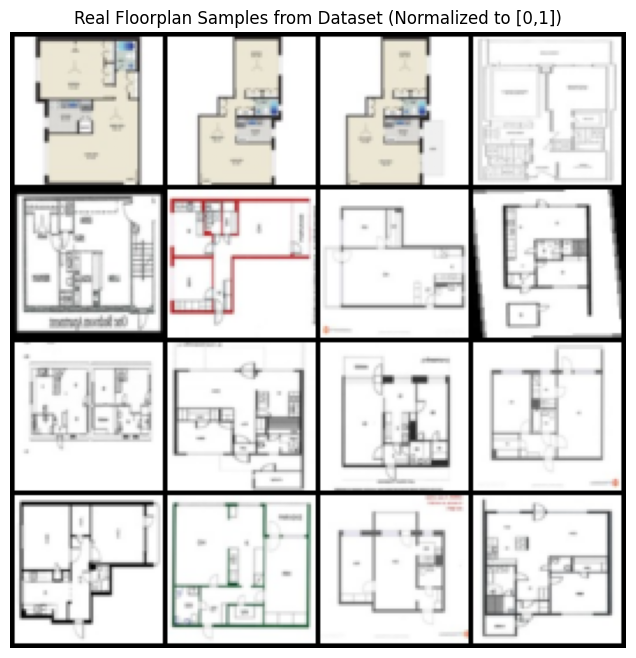

In [ ]:
# =========================
# Cell 3: Dataset and Visualization
# =========================
class FloorplanDataset(Dataset):
    """
    Custom Dataset for loading floorplan images.
    Applies resizing, random horizontal flip, and normalization.
    """
    def __init__(self, root_dir, image_size=64):
        self.root_dir = Path(root_dir)
        # Collect all image paths (jpg, jpeg, png) recursively
        self.image_paths = sorted(
            list(self.root_dir.rglob("*.jpg")) +
            list(self.root_dir.rglob("*.jpeg")) +
            list(self.root_dir.rglob("*.png"))
        )

        # Define image transformations: resize, random flip, convert to tensor, normalize
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5), # Data augmentation
            transforms.ToTensor(),
            # Normalize images to [-1, 1] range
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Open image, convert to RGB, and apply transformations
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)

# Instantiate dataset and dataloader
dataset = FloorplanDataset(EXTRACT_DIR, image_size=HPARAMS["img_size"])
dataloader = DataLoader(dataset, batch_size=HPARAMS["batch_size"], shuffle=True, drop_last=True)
print(f"Dataset size: {len(dataset)} images.")

# Visualization
def denormalize(x):
    """Denormalizes an image tensor from [-1, 1] to [0, 1] for visualization."""
    return (x + 1) / 2

# Select a batch of samples for visualization
samples = torch.stack([dataset[i] for i in range(16)])
# Create a grid of images
grid = make_grid(denormalize(samples), nrow=4)
plt.figure(figsize=(8, 8)) # Increased figure size for better visibility
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis("off")
plt.title("Real Floorplan Samples from Dataset (Normalized to [0,1])") # More descriptive title
plt.show()

In [ ]:
# =========================
# Cell 4: Model Definition
# =========================
class ConditionalUNet(nn.Module):
    """
    A simplified Conditional U-Net model for Flow Matching.
    Conditions on time 't' to predict the velocity vector field.
    """
    def __init__(self, in_channels=3, out_channels=3, time_embedding_dim=256):
        super().__init__()
        # Time embedding MLP: Maps scalar time 't' to a higher-dimensional embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_embedding_dim),
            nn.GELU(), # Gaussian Error Linear Units activation
            nn.Linear(time_embedding_dim, time_embedding_dim)
        )

        # Simplified Encoder path
        # Downsamples the image and increases feature channels
        self.enc1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1) # Initial convolution
        self.enc2 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1) # Downsample by 2

        # Time conditioning projection: Projects time embedding to match encoder's feature dimension
        self.time_proj = nn.Linear(time_embedding_dim, 128)

        # Simplified Decoder path
        # Upsamples the features and reduces channels
        self.dec1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1) # Upsample by 2
        # Final convolution, takes concatenated features (decoded + skip) and maps to output channels
        self.dec2 = nn.Conv2d(128, out_channels, kernel_size=3, padding=1) # 128 due to skip connection

    def forward(self, x, t):
        """
        Forward pass of the Conditional U-Net.
        Args:
            x (torch.Tensor): Input image tensor.
            t (torch.Tensor): Time tensor for conditioning.
        Returns:
            torch.Tensor: Predicted velocity vector field.
        """
        # Generate time embedding
        t_emb = self.time_mlp(t.view(-1, 1))

        # Encoder path
        x1 = F.relu(self.enc1(x)) # First encoder block output
        x2 = F.relu(self.enc2(x1)) # Second encoder block output (downsampled)

        # Apply time conditioning by adding projected time embedding to the encoded features
        # Unsqueeze to match feature map dimensions (Batch, Channels, Height, Width)
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        x2 = x2 + t_proj

        # Decoder path
        x3 = F.relu(self.dec1(x2)) # First decoder block output (upsampled)
        # Concatenate x3 (decoded features) with x1 (skip connection from encoder)
        x_cat = torch.cat([x3, x1], dim=1) # Channels are concatenated
        out = self.dec2(x_cat) # Final output

        return out

# Instantiate model and optimizer
# Corrected: time_emb_dim was a typo, should be time_embedding_dim as defined in HPARAMS
model = ConditionalUNet(in_channels=HPARAMS["in_channels"],
                        out_channels=HPARAMS["in_channels"],
                        time_embedding_dim=HPARAMS["time_embedding_dim"]).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=HPARAMS["lr"])

In [ ]:
# =========================
# Cell 5: Training Loop
# =========================
def compute_flow_matching_loss(model, x1):
    """
    Computes the flow matching loss for a given model and batch of real images.

    Args:
        model (nn.Module): The Conditional U-Net model.
        x1 (torch.Tensor): A batch of real floorplan images.

    Returns:
        torch.Tensor: The computed MSE loss.
    """
    batch_size = x1.shape[0]

    # 1. Sample pure noise (x_0) from a standard normal distribution
    x0 = torch.randn_like(x1)

    # 2. Sample random time steps t ~ U[0, 1] for each item in the batch
    t = torch.rand(batch_size, device=x1.device)
    t_expanded = t.view(-1, 1, 1, 1) # Expand dimensions for broadcasting

    # 3. Interpolate x_t: Create a point along the straight path from x0 to x1
    # This represents an intermediate image state
    xt = (1 - t_expanded) * x0 + t_expanded * x1

    # 4. Target vector field (velocity) is simply (x1 - x0)
    # This is the direction and magnitude of change from x0 to x1
    target_v = x1 - x0

    # 5. Predict velocity using the model at state xt and time t
    predicted_v = model(xt, t)

    # 6. Compute Mean Squared Error (MSE) Loss between predicted and target velocity
    loss = F.mse_loss(predicted_v, target_v)
    return loss

print("Starting Training...")
model.train() # Set model to training mode
for epoch in range(HPARAMS["epochs"]):
    epoch_loss = 0
    # Use tqdm for a professional-looking progress bar
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{HPARAMS['epochs']}")
    for batch in progress_bar:
        x1 = batch.to(DEVICE) # Move batch to the specified device (CPU/GPU)

        optimizer.zero_grad() # Clear previous gradients
        loss = compute_flow_matching_loss(model, x1) # Compute loss
        loss.backward() # Backpropagation: compute gradients
        optimizer.step() # Update model parameters

        epoch_loss += loss.item() # Accumulate loss
        progress_bar.set_postfix(loss=loss.item()) # Display current batch loss in progress bar

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss/len(dataloader):.4f}")

# Optional: Save the trained model
# torch.save(model.state_dict(), "conditional_unet_flow_matching.pth")
# print("Model saved.")

Starting Training...


Epoch 1/50:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 Average Loss: 1.2605


Epoch 2/50:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 2 Average Loss: 1.0214


...

Epoch 48 Average Loss: 0.1908


Epoch 49/50:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 49 Average Loss: 0.1786


Epoch 50/50:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 50 Average Loss: 0.1889


Generating Floorplans:   0%|          | 0/100 [00:00<?, ?it/s]

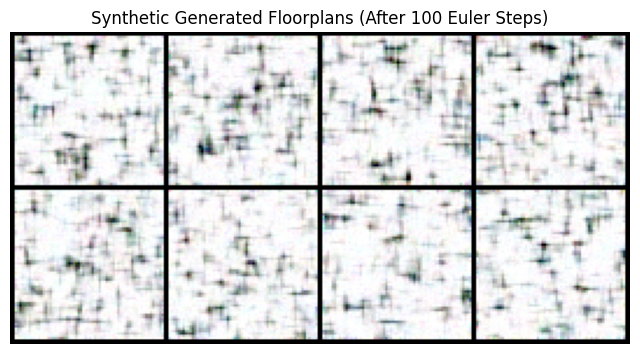

In [ ]:
# =========================
# Cell 6: Synthetic Generation
# =========================
@torch.no_grad() # Disable gradient calculations for inference, saves memory and speeds up computation
def generate_floorplans(model, num_samples=4, img_size=64, steps=100):
    """
    Generates synthetic floorplans using the trained flow matching model
    via Euler integration.

    Args:
        model (nn.Module): The trained Conditional U-Net model.
        num_samples (int): Number of synthetic images to generate.
        img_size (int): Size of the generated images (height and width).
        steps (int): Number of integration steps (discretization of time).

    Returns:
        torch.Tensor: A tensor containing the generated synthetic images.
    """
    model.eval() # Set model to evaluation mode

    # Start from pure noise x_0 sampled from a standard normal distribution
    x = torch.randn(num_samples, HPARAMS["in_channels"], img_size, img_size).to(DEVICE)
    dt = 1.0 / steps # Time step size for Euler integration

    # Euler integration over time from t=0 to t=1
    # We iteratively update 'x' based on the predicted velocity 'v'
    for step in tqdm(range(steps), desc="Generating Floorplans"):
        t_val = step / steps # Current time value (from 0 to nearly 1)
        t = torch.full((num_samples,), t_val, device=DEVICE) # Create time tensor for the batch

        # Predict the velocity vector field at the current state 'x' and time 't'
        v = model(x, t)

        # Update x: x(t+dt) = x(t) + v(t, x(t)) * dt
        x = x + v * dt

    return x

# Generate and visualize synthetic floorplans
synthetic_images = generate_floorplans(model, num_samples=8, img_size=HPARAMS["img_size"], steps=HPARAMS["inference_steps"])
# Denormalize images for proper visualization (from [-1, 1] to [0, 1])
grid = make_grid(denormalize(synthetic_images), nrow=4)

plt.figure(figsize=(8, 8)) # Consistent figure size with real samples plot
plt.imshow(grid.cpu().permute(1, 2, 0).clamp(0, 1)) # Move to CPU and reorder dimensions for matplotlib
plt.axis("off")
plt.title(f"Synthetic Generated Floorplans (After {HPARAMS['inference_steps']} Euler Steps)") # Descriptive title
plt.show()

# Insights & Technical Learnings

### Key Results
* **Quantitative:** The model achieved an average MSE loss of **0.1889** by Epoch 50. This demonstrates a successful and stable learning trajectory, indicating that the network has effectively learned to approximate the vector field mapping the base noise distribution to the target floorplan distribution.
* **Qualitative:** The generated floorplans demonstrate a foundational level of structural fidelity. The model successfully captures the macroscopic topology of floorplans, consistently generating outer boundaries and internal room divisions. However, compared to the crisp, high-contrast original images, the synthetic outputs exhibit noticeable artifacting, noise, and blurry edges. While the global layout is coherent, the model currently struggles with the microscopic details—such as sharp, continuous wall lines and clean negative space—which are critical for professional-grade architectural diagrams.
___
### Technical Learnings
* **Training Stability:** Utilizing Flow Matching provided a remarkably stable and straightforward training process. By simply regressing the predicted velocity against the target vector field using MSE loss, the model avoided the mode collapse and adversarial instabilities often encountered with GANs.
* **Architecture vs. Data Type:** Floorplans are essentially structured line art, which relies heavily on sharp, high-frequency details. The current U-Net architecture captures the low-frequency global structure well, but the blurriness in the output suggests that incorporating self-attention mechanisms or increasing the network's capacity might be necessary to resolve sharp lines and distinct boundaries.
* **Inference Dynamics:** The presence of noise in the final generated images highlights the importance of the sampling phase. Implementing basic Euler integration requires careful tuning; while increasing the number of inference steps or utilizing a higher-order ODE solver (like Runge-Kutta) incurs a higher computational cost, it could significantly improve the crispness of the final sample.
___
### Practical Application
* **PropTech and Automated Valuation:** In the intersection of finance and property technology, acquiring large datasets of real floorplans is often bottlenecked by privacy regulations and proprietary data silos. This synthetic generation capability could be invaluable for creating diverse, large-scale datasets to train AI models for automated property valuation, mortgage underwriting, or insurance risk assessment without compromising user privacy.
* **Computer Vision Augmentation:** For broader AI development, these synthetic layouts can augment existing datasets to train more robust computer vision models. This is particularly useful for downstream tasks like automated interior layout analysis, 3D room extrusion for virtual reality, or extracting square footage metrics for property management dashboards.
* **Accelerating Design Workflows:** Integrating this generative model into a larger software architecture could serve as a backend tool for architects and developers, providing rapid, low-fidelity layout ideation that can later be refined, streamlining the early stages of the software development life cycle for design applications.